In [1]:
import json
import pandas as pd
from cbb.scrape import kenpom
from cbb.lib import paths, teams
import matplotlib.ticker as ticker
pd.set_option('display.colheader_justify', 'center')
ff =  ["Connecticut", "Illinois", "Arizona", "Michigan"]
wff = ["Connecticut", "South Carolina", "UCLA", "Texas"]
M1 = ff[0:2] + wff[0:2]
M2 = ff[2:4] + wff[2:4]
TOT_TEAMS = 364

ff_file = paths.M_KEN_DIR / "2026-03-26.json"
with open(ff_file, "r", encoding="utf-8") as f:
    data = json.load(f)
    
ncaaw_file = paths.W_TOR_DIR / "2026-03-15.json"
with open(ncaaw_file, "r", encoding="utf-8") as f:
    wdata = json.load(f)

kenpom_data = pd.DataFrame(data["rows"], columns=data["headers"])
tourney_teams = kenpom_data[kenpom_data["Seed"] > 0].sort_values(by="Seed")
tourney_teams = tourney_teams.rename(columns={"TeamName" : "Team"})
tourney_teams["ff"] = tourney_teams["Team"].isin(ff)

w_data = pd.DataFrame(wdata["rows"], columns=wdata["headers"])
w_data["ff"] = w_data["Team"].isin(wff)

def highlight_specific_matchup(row):
    if row['Team'] in M1:
        return ['background-color: paleturquoise'] * len(row)
    elif row['Team'] in M2:
        return ['background-color: salmon'] * len(row)
    else:
        return [''] * len(row)

In [2]:
def logos(row):
    if row['ff'] == 1:
        return teams.getTeamLogoShort(row["Team"])
    else:
        return ''
tourney_teams["logo"] = tourney_teams.apply(lambda x: logos(x), axis =1)
w_data["logo"] = w_data.apply(lambda x: logos(x), axis =1)

##  Final Four Stats
# Men's Free Throw Rankings  

In [3]:
# Free Throw Data 
tourney_teams["FTPercentile"] = 100*((TOT_TEAMS - tourney_teams["RankFTPct"]) / TOT_TEAMS)
s16 = tourney_teams[tourney_teams["ff"] == True]
s16 = s16.rename(columns={"FTPct":"FT %", "RankFTPct" : "Natl. Rank", "FTPercentile" : "Percentile"})
ftr = s16[["Team","Seed", "FT %", "Natl. Rank", "Percentile"]].sort_values(by="FT %", ascending=False)
ftr['Percentile'] = ftr["Percentile"].round(0)
ftr = ftr.style \
    .hide(axis='index') \
    .apply(highlight_specific_matchup, axis=1) \
    .set_properties(**{'text-align': 'center'}).set_table_styles([
        dict(selector='th', props=[('text-align', 'center')]) 
    ]) \
    .format({'FT %': '{:.2%}'}) \
    .format({"Percentile" : "{:.0f}th".format})

ftr

Team,Seed,FT %,Natl. Rank,Percentile
Illinois,3,78.437000,13,96th
Michigan,1,74.692900,96,74th
Arizona,1,72.992700,170,53th
Connecticut,2,72.213500,200,45th


## Final Four Charts

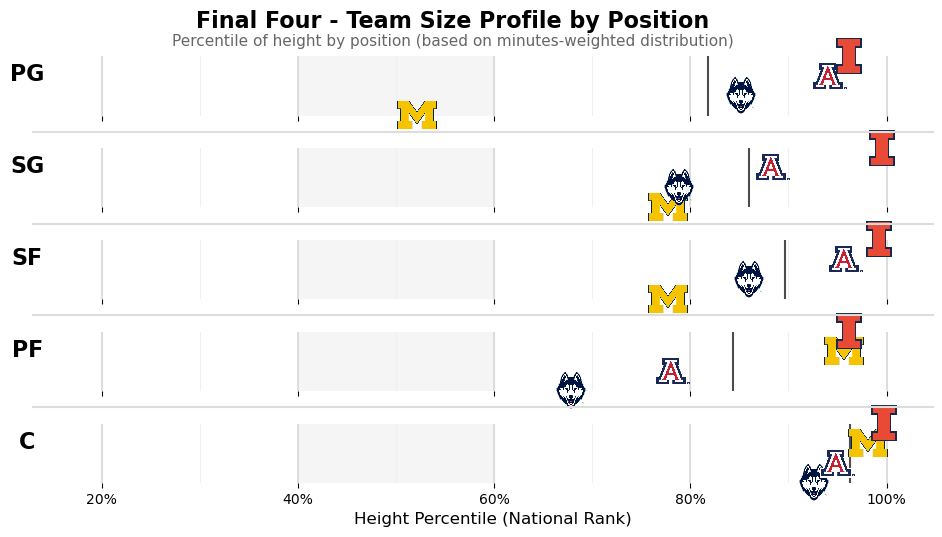

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# -----------------------------
# Setup
# -----------------------------
df = tourney_teams[[
    "Team", "Seed", "ff", "logo",
    "Hgt1Rank", "Hgt2Rank", "Hgt3Rank", "Hgt4Rank", "Hgt5Rank"
]]

df = df.rename(columns={
    "Hgt1Rank": "PG",
    "Hgt2Rank": "SG",
    "Hgt3Rank": "SF",
    "Hgt4Rank": "PF",
    "Hgt5Rank": "C"
})

positions = ["PG", "SG", "SF", "PF", "C"]

# -----------------------------
# Convert ranks → percentiles FIRST
# -----------------------------
for pos in positions:
    df[pos] = 1 - (df[pos] - 1) / (TOT_TEAMS - 1)

df_plot = df[df["ff"] == 1].reset_index(drop=True)

# -----------------------------
# Figure
# -----------------------------
fig_height = 0.8 * len(df_plot) + 2
fig, axes = plt.subplots(5, 1, figsize=(10, fig_height), sharex=True)

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.90,
    bottom=0.08,
    hspace=0.55
)

# -----------------------------
# X range
# -----------------------------
x_min = df_plot[positions].min().min()
x_max = df_plot[positions].max().max()

x_min = min(x_min, 0.2)
x_max = max(x_max, 0.8)

pad = 0.05
x_min = max(0, x_min - pad)
x_max = min(1.15, x_max + pad)

# -----------------------------
# Percentile ticks
# -----------------------------
major_ticks = np.arange(0, 1.01, 0.2)   # 0,20,...100
minor_ticks = np.arange(0, 1.01, 0.1)   # 10% steps

major_ticks = [t for t in major_ticks if x_min <= t <= x_max]
minor_ticks = [t for t in minor_ticks if x_min <= t <= x_max]

# -----------------------------
# Plot
# -----------------------------
for i, pos in enumerate(positions):
    ax = axes[i]

    temp = df_plot.sort_values(pos).reset_index(drop=True)
    y_vals = np.arange(len(temp))

    # 🔥 Background band (average)
    ax.axvspan(0.4, 0.6, color="#f5f5f5", zorder=0)

    # 🔥 Minor grid (light)
    for t in minor_ticks:
        ax.axvline(t, color="#f0f0f0", linewidth=0.8, zorder=0)

    # 🔥 Major grid (stronger)
    for t in major_ticks:
        ax.axvline(t, color="#d9d9d9", linewidth=1.2, zorder=0)

    # 🔥 Logos
    for j, row in temp.iterrows():
        x = row[pos]
        y = j

        path = paths.ASSET_IMG_DIR / row["logo"]
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.055)

        ab = AnnotationBbox(im, (x, y), frameon=False)
        ax.add_artist(ab)

    # 🔥 Average line
    avg = temp[pos].mean()
    ax.axvline(avg, color="black", linewidth=1.5, alpha=0.7)

    # Remove labels but keep spacing
    ax.set_yticks(y_vals)
    ax.set_yticklabels([])


    ax.set_xlim(x_min, x_max)

    # 🔥 Show ticks on EVERY subplot
    ax.set_xticks(major_ticks)
    ax.set_xticklabels([f"{int(t*100)}%" for t in major_ticks], fontsize=10)
    
    ax.set_ylabel(pos, rotation=0, fontsize=16, fontweight="bold", labelpad=15)

for i in range(len(axes) - 1):
    # bottom of current axis
    y_top_next = axes[i+1].get_position().y1
    y_bottom_current = axes[i].get_position().y0

    # midpoint of the gap between plots
    y = (y_bottom_current + y_top_next) / 2

    fig.add_artist(plt.Line2D(
        [0.08, 0.98],   # match your left/right margins
        [y, y],
        transform=fig.transFigure,
        color="#dddddd",
        linewidth=1.5
    ))

# -----------------------------
# Bottom label
# -----------------------------
axes[-1].set_xlabel("Height Percentile (National Rank)", fontsize=12)

# -----------------------------
# Clean styling
# -----------------------------
for ax in axes:
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='y', length=0)

# -----------------------------
# Titles
# -----------------------------
fig.suptitle(
    "Final Four - Team Size Profile by Position",
    fontsize=16,
    fontweight="bold",
    y=0.99
)

fig.text(
    0.5, 0.92,
    "Percentile of height by position (based on minutes-weighted distribution)",
    ha="center",
    fontsize=11,
    color="#666"
)

plt.show()

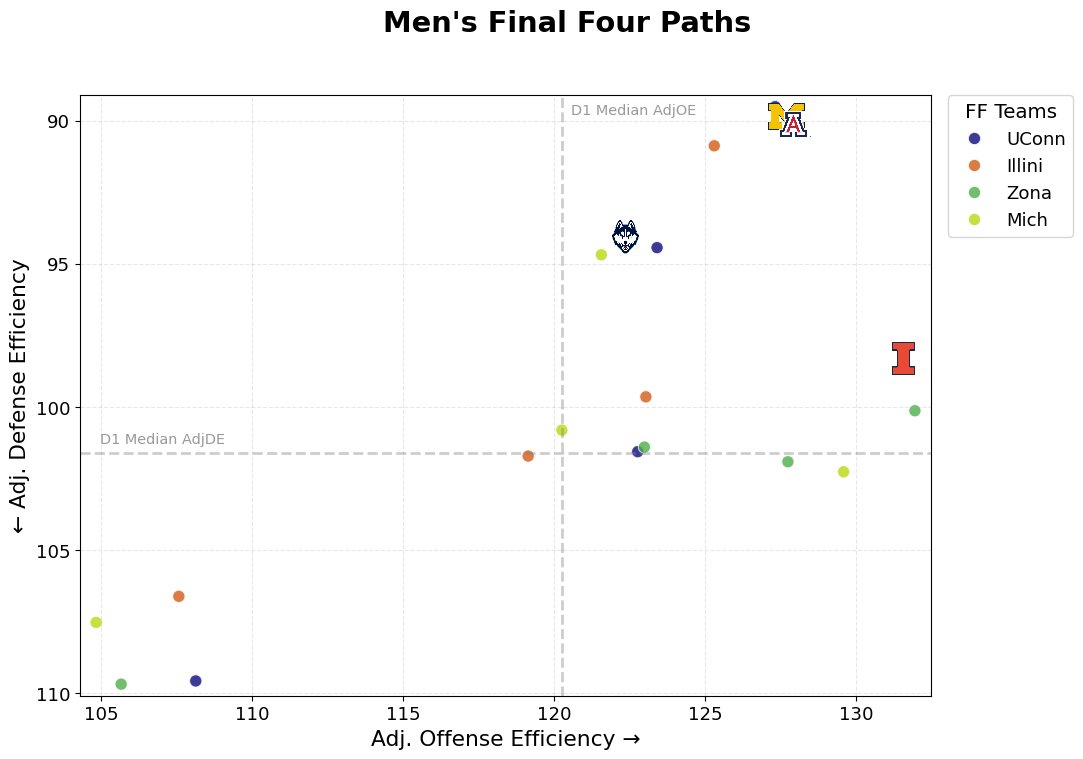

In [5]:

# Efficiency
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

SCALE = 1.3
uconn = ["Furman", "UCLA", "Michigan St.", "Duke"]
illini = ["Penn", "VCU", "Houston", "Iowa"]
zona = ["LIU", "Utah St.", "Arkansas", "Purdue"]
michigan = ["Howard", "Saint Louis", "Alabama", "Tennessee"]

eff = tourney_teams[["Team","Seed", "AdjOE", "AdjDE", 'ff', 'logo']].copy()

def assign_group(team):
    if team in uconn:
        return "UConn"
    elif team in illini:
        return "Illini"
    elif team in zona:
        return "Zona"
    elif team in michigan:
        return "Mich"
    else:
        return 0

eff["Group"] = eff["Team"].apply(assign_group)

palette = {
    "UConn": "#0c0a7c",   # red
    "Illini": "#d35b16",   # blue
    "Zona": "#4daf4a",   # green
    "Mich": "#bbd813",   # purple
}

x_median = eff["AdjOE"].median()
y_median = eff["AdjDE"].median()

fig, ax = plt.subplots(figsize=(10*SCALE, 6*SCALE))

eff_ff = eff[eff["Group"] != 0]

sns.scatterplot(
    data=eff_ff,
    x='AdjOE',
    y='AdjDE',
    hue='Group',
    palette=palette,
    alpha=0.8,
    s=60*SCALE,
    ax=ax
)
ax.invert_yaxis()

for i, row in eff.iterrows():
    if row['ff'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.04*SCALE) 
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['AdjOE'], row['AdjDE']), frameon=False)
        ax.add_artist(ab)

fig.suptitle(
    "Men's Final Four Paths",
    fontsize=16*SCALE,
    fontweight="bold",
    y=0.99
)

ax.set_xlabel("Adj. Offense Efficiency →", fontsize=12*SCALE)
ax.set_ylabel("← Adj. Defense Efficiency", fontsize=12*SCALE)

ax.legend(
    title="FF Teams",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=10*SCALE,
    title_fontsize=11*SCALE
)

ax.tick_params(axis='both', labelsize=10*SCALE)

ax.axvline(x=x_median, linestyle='--', linewidth=1.5*SCALE, color='gray', alpha=0.4)
ax.axhline(y=y_median, linestyle='--', linewidth=1.5*SCALE, color='gray', alpha=0.4)

x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
y_range = ax.get_ylim()[1] - ax.get_ylim()[0]

# Custom offsets
x_offset_small = x_range * 0.01
x_offset_big = x_range * 0.05      # 👈 push further right

y_offset_small = y_range * 0.01
y_offset_down = y_range * 0.04     # 👈 push downward

ax.text(
    x_median + x_offset_small,
    ax.get_ylim()[1] - y_offset_down,
    "D1 Median AdjOE",
    ha='left',
    va='top',
    fontsize=8*SCALE,
    color='gray',
    alpha=0.8
)

ax.text(
    ax.get_xlim()[0] + x_offset_big,
    y_median + y_offset_small,
    "D1 Median AdjDE",
    ha='left',
    va='bottom',
    fontsize=8*SCALE,
    color='gray',
    alpha=0.8
)

plt.subplots_adjust(right=0.78)
ax.margins(x=0.02, y=0.02)

ax.grid(True, linestyle='--', alpha=0.3)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

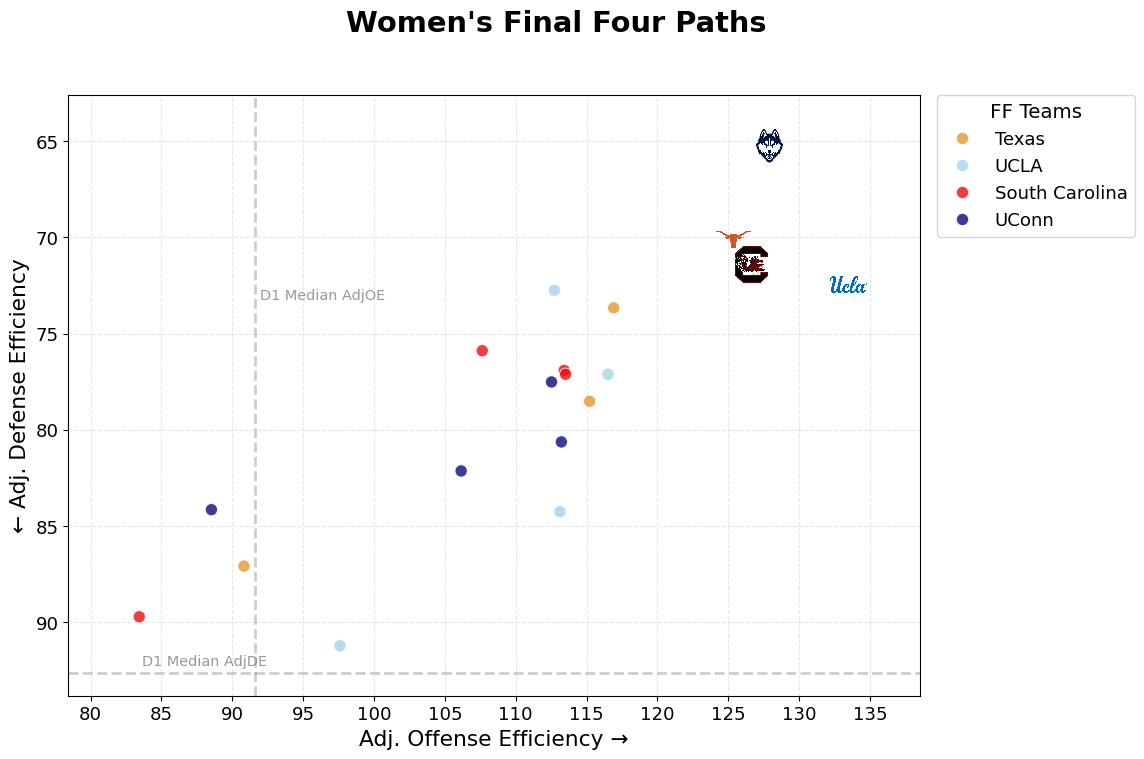

In [6]:

# Efficiency
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

SCALE = 1.3
uconn = ["UTSA", "Syracuse", "North Carolina", "Notre Dame"]
ucla = ["Cal Baptist", "Oklahoma St.", "Minnesota", "Duke"]
texas = ["Missouri St.", "Oregon.", "Kentucky", "Michigan"]
sc = ["Southern", "USC", "Oklahoma", "TCU"]

eff = w_data[["Team", "AdjOE", "AdjDE", 'ff', 'logo']].copy()
eff['AdjOE'] = pd.to_numeric(eff['AdjOE'])
eff['AdjDE'] = pd.to_numeric(eff['AdjDE'])
def assign_group(team):
    if team in uconn:
        return "UConn"
    elif team in ucla:
        return "UCLA"
    elif team in texas:
        return "Texas"
    elif team in sc:
        return "South Carolina"
    else:
        return 0

eff["Group"] = eff["Team"].apply(assign_group)

palette = {
    "UConn": "#0c0a7c",   # red
    "UCLA": "#a8d2ea",   # blue
    "Texas": "#e4982d",   # green
    "South Carolina": "#ee0d0d",   # purple
}

x_median = eff["AdjOE"].median()
y_median = eff["AdjDE"].median()

fig, ax = plt.subplots(figsize=(10*SCALE, 6*SCALE))

eff_ff = eff[eff["Group"] != 0]

sns.scatterplot(
    data=eff_ff,
    x='AdjOE',
    y='AdjDE',
    hue='Group',
    palette=palette,
    alpha=0.8,
    s=60*SCALE,
    ax=ax
)
ax.invert_yaxis()

for i, row in eff.iterrows():
    if row['ff'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.04*SCALE) 
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['AdjOE'], row['AdjDE']), frameon=False)
        ax.add_artist(ab)

fig.suptitle(
    "Women's Final Four Paths",
    fontsize=16*SCALE,
    fontweight="bold",
    y=0.99
)

ax.set_xlabel("Adj. Offense Efficiency →", fontsize=12*SCALE)
ax.set_ylabel("← Adj. Defense Efficiency", fontsize=12*SCALE)

ax.legend(
    title="FF Teams",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=10*SCALE,
    title_fontsize=11*SCALE
)

ax.tick_params(axis='both', labelsize=10*SCALE)

ax.axvline(x=x_median, linestyle='--', linewidth=1.5*SCALE, color='gray', alpha=0.4)
ax.axhline(y=y_median, linestyle='--', linewidth=1.5*SCALE, color='gray', alpha=0.4)

x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
y_range = ax.get_ylim()[1] - ax.get_ylim()[0]

# Custom offsets
x_offset_small = x_range * 0.01
x_offset_big = x_range * 0.05      # 👈 push further right

y_offset_small = y_range * 0.01
y_offset_down = y_range * 0.04     # 👈 push downward

ax.text(
    x_median + x_offset_small,
    ax.get_ylim()[1] - y_offset_down,
    "D1 Median AdjOE",
    ha='left',
    va='top',
    fontsize=8*SCALE,
    color='gray',
    alpha=0.8
)

ax.text(
    ax.get_xlim()[0] + x_offset_big,
    y_median + y_offset_small,
    "D1 Median AdjDE",
    ha='left',
    va='bottom',
    fontsize=8*SCALE,
    color='gray',
    alpha=0.8
)

plt.subplots_adjust(right=0.78)
ax.margins(x=0.02, y=0.02)

ax.grid(True, linestyle='--', alpha=0.3)

chart = eff[(eff["Group"] != 0) | (eff['ff'] == 1)]
# 1. Calculate the bounds of your FF teams
x_margin = (chart['AdjOE'].max() - chart['AdjOE'].min()) * 0.1
y_margin = (chart['AdjDE'].max() - chart['AdjDE'].min()) * 0.1

# 2. Set limits to include all FF teams with a small buffer
ax.set_xlim(chart['AdjOE'].min() - x_margin, chart['AdjOE'].max() + x_margin)
# Remember: AdjDE is inverted, so 'min' is the top of the chart
ax.set_ylim(chart['AdjDE'].max() + y_margin, chart['AdjDE'].min() - y_margin) 
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

plt.show()

